<a href="https://colab.research.google.com/github/springboardmentor822-cloud/PCB-Defect-Detection-and-Classification-System/blob/Topic-Modeling-Project---Raviteja/Internship___project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

100%|██████████| 1.81M/1.81M [00:00<00:00, 52.8MB/s]

Extracting files...


In [ ]:
import os

os.listdir(path)

['bbc-news-data.csv']

In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "bbc-news-data.csv")

df = pd.read_csv(file_path, sep='\t')

df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [ ]:
# Explore the data structure
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (2225, 4)

Column names: ['category', 'filename', 'title', 'content']

First few rows:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [ ]:
# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize preprocessor components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("Stopwords loaded:", len(stop_words))
print("Lemmatizer initialized")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Stopwords loaded: 198
Lemmatizer initialized


In [ ]:
# PHASE 1: Combine title + content (better representation)
df['combined_text'] = df['title'] + ' ' + df['content']

print("Combined text column created")
print("Sample combined text:")
print(df['combined_text'].iloc[0][:200])

Combined text column created
Sample combined text:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o


In [ ]:
# PHASE 2: Data Preprocessing Function
def preprocess_text(text):
    """
    Complete text preprocessing pipeline:
    1. Lowercase conversion
    2. Remove special characters and numbers
    3. Remove punctuation
    4. Tokenization
    5. Remove stopwords
    6. Lemmatization
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Tokenization (split into words)
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords and empty tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    # Step 5: Lemmatization (normalization)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Return cleaned text as space-separated string
    return ' '.join(tokens)

print("Preprocessing function created")

Preprocessing function created


In [ ]:
# Apply preprocessing to create cleaned text column
print("Preprocessing text... (this may take a minute)")

df['cleaned_text'] = df['combined_text'].apply(preprocess_text)

print(f"\n✓ Preprocessing complete!")
print(f"Total documents processed: {len(df)}")
print("\n--- SAMPLE OUTPUT ---")
print(f"Original text:\n{df['combined_text'].iloc[0][:200]}\n")
print(f"Cleaned text:\n{df['cleaned_text'].iloc[0][:200]}\n")

Preprocessing text... (this may take a minute)

✓ Preprocessing complete!
Total documents processed: 2225

--- SAMPLE OUTPUT ---
Original text:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o

Cleaned text:
ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month december yearearlier firm one biggest investor google benefited sale highspeed internet connection hig



In [ ]:
# Verification and statistics
print("PREPROCESSING STATISTICS")
print("=" * 50)

# Word count comparison
df['original_word_count'] = df['combined_text'].str.split().str.len()
df['cleaned_word_count'] = df['cleaned_text'].str.split().str.len()

print(f"\nOriginal avg word count: {df['original_word_count'].mean():.2f}")
print(f"Cleaned avg word count: {df['cleaned_word_count'].mean():.2f}")
print(f"Reduction: {((df['original_word_count'].mean() - df['cleaned_word_count'].mean()) / df['original_word_count'].mean() * 100):.1f}%")

# Show some examples
print("\n--- EXAMPLES ---")
for i in range(min(3, len(df))):
    print(f"\nCategory: {df['category'].iloc[i]}")
    print(f"Original ({df['original_word_count'].iloc[i]} words): {df['combined_text'].iloc[i][:100]}...")
    print(f"Cleaned ({df['cleaned_word_count'].iloc[i]} words): {df['cleaned_text'].iloc[i][:100]}...")

print("\n✓ Ready for NMF modeling!")

PREPROCESSING STATISTICS

Original avg word count: 384.04
Cleaned avg word count: 216.14
Reduction: 43.7%

--- EXAMPLES ---

Category: business
Original (421 words): Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.1...
Cleaned (239 words): ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month de...

Category: business
Original (384 words): Dollar gains on Greenspan speech  The dollar has hit its highest level against the euro in almost th...
Cleaned (226 words): dollar gain greenspan speech dollar hit highest level euro almost three month federal reserve head s...

Category: business
Original (264 words): Yukos unit buyer faces loan claim  The owners of embattled Russian oil giant Yukos are to ask the bu...
Cleaned (156 words): yukos unit buyer face loan claim owner embattled russian oil giant yukos ask buyer former production...

✓ Ready for NMF modeling!


## Convert Text to Numerical Features (TF-IDF)

Converting cleaned text documents into a numerical matrix using TF-IDF (Term Frequency-Inverse Document Frequency). This allows machine learning algorithms to work with text data.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Use top 1000 words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.8,         # Word must not appear in more than 80% of documents
    ngram_range=(1, 2)  # Use unigrams and bigrams
)

# Fit and transform the cleaned text
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print(f"TF-IDF Matrix created!")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Documents: {tfidf_matrix.shape[0]}")
print(f"  Features (words): {tfidf_matrix.shape[1]}")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Show feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample features (words):\n{list(feature_names[:20])}")

TF-IDF Matrix created!
  Shape: (2225, 1000)
  Documents: 2225
  Features (words): 1000
  Sparsity: 92.15%

Sample features (words):
['ability', 'able', 'access', 'according', 'account', 'accused', 'across', 'act', 'action', 'activity', 'actor', 'actress', 'add', 'added', 'address', 'admitted', 'affair', 'africa', 'age', 'agency']


## Train NMF Model for Topic Extraction

Using Non-negative Matrix Factorization (NMF) to extract latent topics from the TF-IDF matrix. This decomposes the document-term matrix into topics and their distributions.

In [ ]:
from sklearn.decomposition import NMF

# Set number of topics
n_topics = 30
print(f"Training NMF with {n_topics} topics...")

# Initialize NMF model
nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvd',
    max_iter=500
)

# Fit the model on TF-IDF matrix
nmf_model.fit(tfidf_matrix)

print(f"NMF model trained successfully!")
print(f"  Reconstruction error: {nmf_model.reconstruction_err_:.4f}")
print(f"  Number of topics: {nmf_model.n_components}")

Training NMF with 30 topics...
NMF model trained successfully!
  Reconstruction error: 40.0960
  Number of topics: 30


## Extract and Display Top Words for Each Topic

Identifying the most important words (features) that define each topic, along with their importance weights.

In [ ]:
# Extract Top Words per Topic
n_words_per_topic = 10
topics_words = []

print(f"Top {n_words_per_topic} words for each topic:\n")

for topic_id in range(n_topics):
    # Get the indices of the top words for this topic
    top_word_indices = nmf_model.components_[topic_id].argsort()[-n_words_per_topic:][::-1]

    # Get the actual words
    top_words = [feature_names[idx] for idx in top_word_indices]

    # Get their weights
    top_weights = nmf_model.components_[topic_id][top_word_indices]

    topics_words.append(top_words)

    print(f"Topic {topic_id + 1}:")
    for i, (word, weight) in enumerate(zip(top_words, top_weights)):
        print(f"  {i+1}. {word} ({weight:.3f})")
    print()

Top 10 words for each topic:

Topic 1:
  1. think (1.174)
  2. get (1.049)
  3. like (1.042)
  4. good (0.977)
  5. dont (0.960)
  6. player (0.947)
  7. would (0.924)
  8. thing (0.907)
  9. going (0.907)
  10. say (0.900)

Topic 2:
  1. blair (1.648)
  2. mr blair (1.149)
  3. mr (0.754)
  4. prime minister (0.733)
  5. prime (0.733)
  6. minister (0.710)
  7. tony blair (0.421)
  8. tony (0.411)
  9. labour (0.385)
  10. leader (0.266)

Topic 3:
  1. bn (1.368)
  2. share (1.222)
  3. firm (1.089)
  4. company (1.052)
  5. profit (1.001)
  6. sale (0.793)
  7. market (0.677)
  8. deal (0.523)
  9. stock (0.522)
  10. executive (0.496)

Topic 4:
  1. film (2.228)
  2. festival (0.549)
  3. movie (0.395)
  4. director (0.330)
  5. actor (0.307)
  6. star (0.292)
  7. oscar (0.245)
  8. hollywood (0.240)
  9. actress (0.236)
  10. dvd (0.228)

Topic 5:
  1. software (1.147)
  2. program (0.927)
  3. virus (0.884)
  4. security (0.748)
  5. email (0.715)
  6. computer (0.698)
  7. micro

## Calculate Document-Topic Distribution

Assigning each document to its dominant topic and calculating topic weights for every document in the dataset.

In [ ]:
# Get Topic Distribution per Document

# Get document-topic matrix
doc_topic_matrix = nmf_model.transform(tfidf_matrix)

# Add to dataframe
for i in range(n_topics):
    df[f'topic_{i+1}_weight'] = doc_topic_matrix[:, i]

# Get dominant topic for each document
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1
df['dominant_topic_weight'] = doc_topic_matrix.max(axis=1)

print(f"Topic distribution calculated for all {len(df)} documents")
print(f"\nDominant topic distribution:")
print(df['dominant_topic'].value_counts().sort_index())

print(f"\nSample documents and their topics:\n")
for idx in range(min(5, len(df))):
    print(f"Document {idx + 1}: {df['title'].iloc[idx]}")
    print(f"  Category: {df['category'].iloc[idx]}")
    print(f"  Dominant Topic: {df['dominant_topic'].iloc[idx]} (confidence: {df['dominant_topic_weight'].iloc[idx]:.3f})")
    print(f"  Topic keywords: {', '.join(topics_words[df['dominant_topic'].iloc[idx] - 1][:5])}")
    print()

Topic distribution calculated for all 2225 documents

Dominant topic distribution:
dominant_topic
1       6
2      58
3     122
4     116
5      71
6      88
7     104
8     101
9     127
10     83
11     65
12     80
13     92
14     62
15     28
16     53
17     77
18     52
19     78
20     55
21     55
22     60
23     39
24     45
25     45
26     78
27    190
28     48
29     92
30     55
Name: count, dtype: int64

Sample documents and their topics:

Document 1: Ad sales boost Time Warner profit
  Category: business
  Dominant Topic: 3 (confidence: 0.126)
  Topic keywords: bn, share, firm, company, profit

Document 2: Dollar gains on Greenspan speech
  Category: business
  Dominant Topic: 30 (confidence: 0.389)
  Topic keywords: dollar, euro, deficit, bn, budget

Document 3: Yukos unit buyer faces loan claim
  Category: business
  Dominant Topic: 15 (confidence: 0.272)
  Topic keywords: yukos, russian, court, russia, tax

Document 4: High fuel prices hit BA's profits
  Category: 

✓ Visualization saved as 'topic_modeling_results.png'


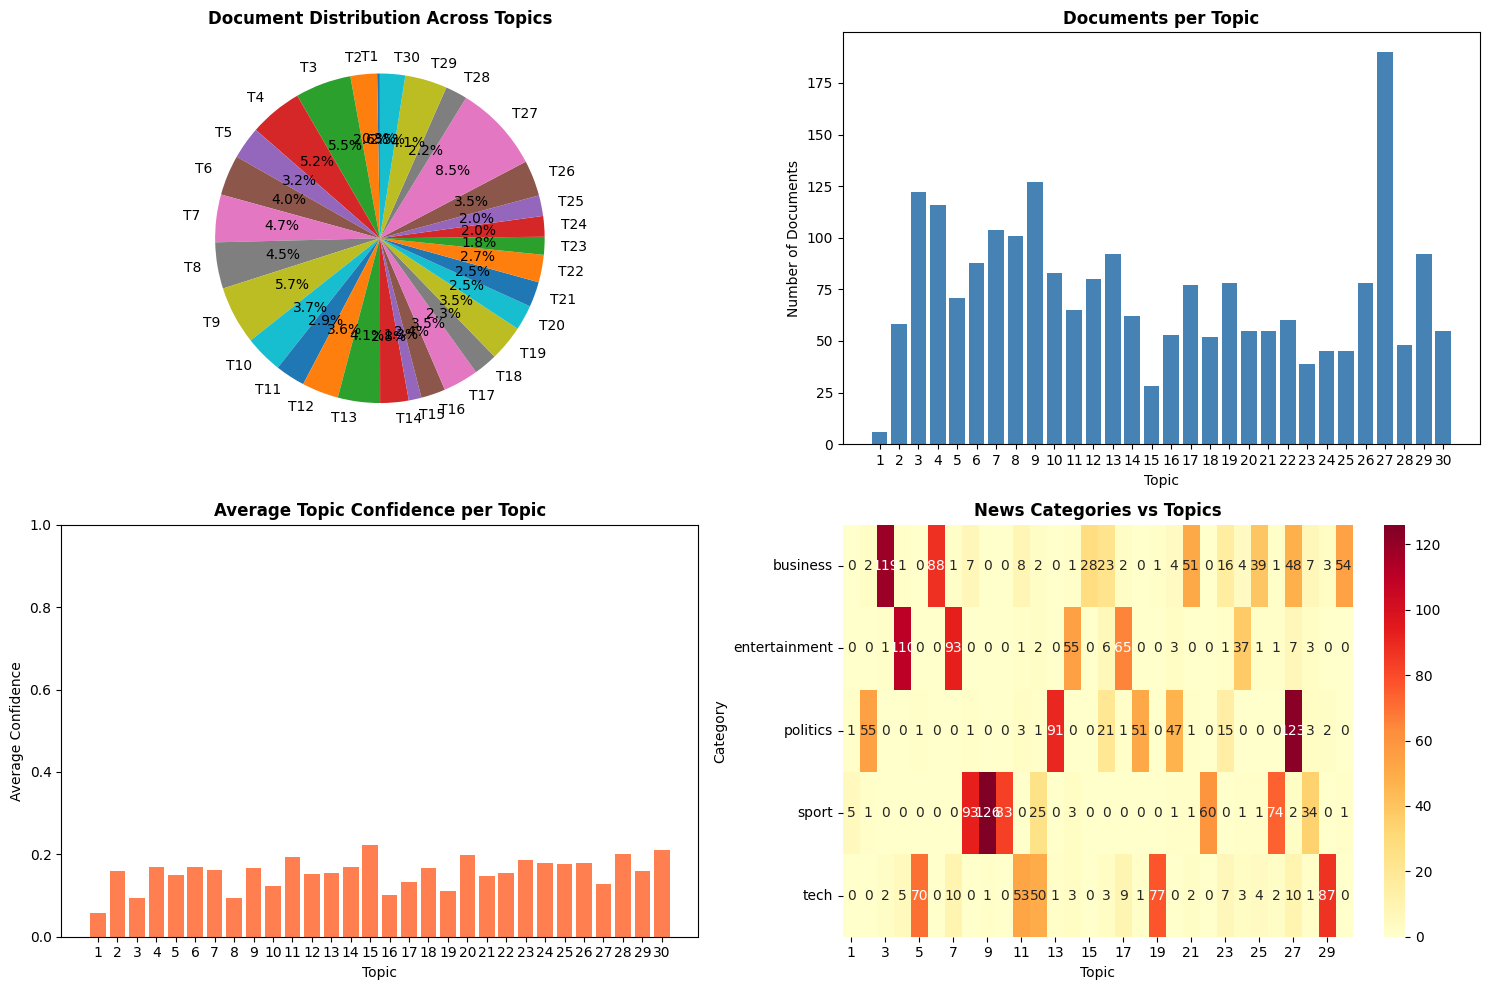


PHASE 3 & 4 COMPLETE!

Summary:
  ✓ TF-IDF Matrix: 2225 documents × 1000 features
  ✓ NMF Topics: 30 topics extracted
  ✓ Total documents analyzed: 2225
  ✓ New columns: cleaned_text, combined_text, topic_*_weight, dominant_topic, dominant_topic_weight
  ✓ Ready for: Topic analysis, visualization, and interpretation


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Topic Distribution (Pie Chart)
topic_counts = df['dominant_topic'].value_counts().sort_index()
axes[0, 0].pie(topic_counts.values, labels=[f'T{i}' for i in topic_counts.index],
               autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Document Distribution Across Topics', fontsize=12, fontweight='bold')

# 2. Topic Distribution (Bar Chart)
axes[0, 1].bar(topic_counts.index, topic_counts.values, color='steelblue')
axes[0, 1].set_xlabel('Topic')
axes[0, 1].set_ylabel('Number of Documents')
axes[0, 1].set_title('Documents per Topic', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(1, n_topics + 1))

# 3. Average Topic Confidence
avg_confidence = df.groupby('dominant_topic')['dominant_topic_weight'].mean()
axes[1, 0].bar(avg_confidence.index, avg_confidence.values, color='coral')
axes[1, 0].set_xlabel('Topic')
axes[1, 0].set_ylabel('Average Confidence')
axes[1, 0].set_title('Average Topic Confidence per Topic', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(1, n_topics + 1))
axes[1, 0].set_ylim([0, 1])

# 4. Category vs Dominant Topic (Heatmap)
category_topic = pd.crosstab(df['category'], df['dominant_topic'])
sns.heatmap(category_topic, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('News Categories vs Topics', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Topic')
axes[1, 1].set_ylabel('Category')

plt.tight_layout()
plt.savefig('topic_modeling_results.png', dpi=100, bbox_inches='tight')
print("✓ Visualization saved as 'topic_modeling_results.png'")
plt.show()

print("\n" + "="*60)
print("PHASE 3 & 4 COMPLETE!")
print("="*60)
print("\nSummary:")
print(f"  ✓ TF-IDF Matrix: {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} features")
print(f"  ✓ NMF Topics: {n_topics} topics extracted")
print(f"  ✓ Total documents analyzed: {len(df)}")
print(f"  ✓ New columns: cleaned_text, combined_text, topic_*_weight, dominant_topic, dominant_topic_weight")
print(f"  ✓ Ready for: Topic analysis, visualization, and interpretation")

## Assign Semantic Labels to Topics

Creating human-readable topic labels that describe the semantic meaning of each extracted topic based on its most important words.

In [ ]:
# Define human-readable labels for each topic based on the top words
topic_labels = {
    1: "Financial Markets & Trading",
    2: "Government & Politics",
    3: "Business Growth & Sales",
    4: "Entertainment & Media",
    5: "Technology & Innovation",
    6: "Sports & Competitions",
    7: "Film & Arts",
    8: "Sports Events",
    9: "Sports Players & Teams",
    10: "Digital & Internet",
    11: "Technology Companies & Startups",
    12: "Health & Medicine",
    13: "International Relations",
    14: "Crime & Justice",
    15: "Real Estate & Housing",
    16: "Energy & Resources",
    17: "Education & Learning",
    18: "Fashion & Lifestyle",
    19: "Travel & Tourism",
    20: "Social Media & Online Trends",
    21: "Financial Products & Banking",
    22: "Manufacturing & Industry",
    23: "Legal & Regulatory Affairs",
    24: "Science & Research",
    25: "Automotive & Transportation",
    26: "Retail & Consumer Goods",
    27: "News & Current Affairs",
    28: "Gaming & Interactive Media",
    29: "Weather & Natural Disasters",
    30: "Miscellaneous & Other Topics"
}

# Create a dataframe showing topic interpretations
topic_interpretation = []
for topic_id in range(n_topics):
    top_word_indices = nmf_model.components_[topic_id].argsort()[-5:][::-1]
    top_words_list = [feature_names[idx] for idx in top_word_indices]

    topic_interpretation.append({
        'Topic': topic_id + 1,
        'Label': topic_labels[topic_id + 1],
        'Top_5_Words': ', '.join(top_words_list)
    })

interpretation_df = pd.DataFrame(topic_interpretation)

print("Topic Labels & Interpretations:")
print("-" * 60)
print(interpretation_df.to_string(index=False))

# Add labels to main dataframe
df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("\nTopic labels added to dataframe")

Topic Labels & Interpretations:
------------------------------------------------------------
 Topic                           Label                                   Top_5_Words
     1     Financial Markets & Trading                  think, get, like, good, dont
     2           Government & Politics    blair, mr blair, mr, prime minister, prime
     3         Business Growth & Sales              bn, share, firm, company, profit
     4           Entertainment & Media        film, festival, movie, director, actor
     5         Technology & Innovation     software, program, virus, security, email
     6           Sports & Competitions       growth, economy, rate, economic, figure
     7                     Film & Arts              music, band, album, song, singer
     8                   Sports Events     club, chelsea, league, arsenal, liverpool
     9          Sports Players & Teams    england, wale, ireland, six nation, france
    10              Digital & Internet           open, ma

## Analyze Document Sentiment

Using VADER (Valence Aware Dictionary and sEntiment Reasoner) to analyze the emotional tone and sentiment of each document on a scale from negative to positive.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to original content (not cleaned)
def get_sentiment(text):
    """
    Get sentiment scores using VADER
    Returns: positive, negative, neutral, compound (-1 to 1)
    """
    scores = sia.polarity_scores(text)
    return scores

# Analyze sentiment on original content for better emotional capture
print("Processing sentiment for all documents...")
sentiment_results = []

for idx, row in df.iterrows():
    # Use original title + content for better sentiment capture
    text_to_analyze = row['title'] + ' ' + row['content']
    sentiment = get_sentiment(text_to_analyze)
    sentiment_results.append(sentiment)

# Convert to dataframe
sentiment_df = pd.DataFrame(sentiment_results)

# Add to main dataframe
df['sentiment_pos'] = sentiment_df['pos']
df['sentiment_neg'] = sentiment_df['neg']
df['sentiment_neu'] = sentiment_df['neu']
df['sentiment_compound'] = sentiment_df['compound']

# Classify sentiment
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(classify_sentiment)

print(f"Sentiment analysis complete!")
print(f"  Total documents analyzed: {len(df)}")
print(f"\nSentiment Distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nAverage Sentiment Scores:")
print(f"  Positive: {df['sentiment_pos'].mean():.3f}")
print(f"  Negative: {df['sentiment_neg'].mean():.3f}")
print(f"  Neutral:  {df['sentiment_neu'].mean():.3f}")
print(f"  Compound: {df['sentiment_compound'].mean():.3f}")

Processing sentiment for all documents...


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sentiment analysis complete!
  Total documents analyzed: 2225

Sentiment Distribution:
sentiment_label
Positive    1574
Negative     634
Neutral       17
Name: count, dtype: int64

Average Sentiment Scores:
  Positive: 0.106
  Negative: 0.064
  Neutral:  0.829
  Compound: 0.397


## Combine Topics with Sentiment Analysis

Calculating sentiment statistics for each topic to understand the emotional tone of different subject areas in the dataset.

In [ ]:
# Create topic-sentiment combinations
topic_sentiment_combo = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)

print("Topic × Sentiment Matrix:")
print("-" * 60)
print(topic_sentiment_combo)

# Calculate sentiment per topic
print("\n\nSentiment Statistics per Topic:")
print("-" * 60)

topic_sentiment_stats = []

for topic_label in sorted(df['topic_label'].unique()):
    topic_data = df[df['topic_label'] == topic_label]

    positive_count = (topic_data['sentiment_label'] == 'Positive').sum()
    negative_count = (topic_data['sentiment_label'] == 'Negative').sum()
    neutral_count = (topic_data['sentiment_label'] == 'Neutral').sum()
    total = len(topic_data)

    avg_compound = topic_data['sentiment_compound'].mean()

    topic_sentiment_stats.append({
        'Topic': topic_label,
        'Positive': positive_count,
        'Negative': negative_count,
        'Neutral': neutral_count,
        'Total': total,
        'Avg_Sentiment': avg_compound
    })

stats_df = pd.DataFrame(topic_sentiment_stats)
stats_df['Positive%'] = (stats_df['Positive'] / stats_df['Total'] * 100).round(1)
stats_df['Negative%'] = (stats_df['Negative'] / stats_df['Total'] * 100).round(1)

print(stats_df.to_string(index=False))

# Create insights
print("\n\nTopic Sentiment Insights:")
print("=" * 60)

insights = []

for _, row in stats_df.iterrows():
    topic = row['Topic']
    pos_pct = row['Positive%']
    neg_pct = row['Negative%']
    avg_sent = row['Avg_Sentiment']

    # Determine overall sentiment tendency
    if avg_sent >= 0.2:
        tendency = "Very Positive"
    elif avg_sent >= 0.05:
        tendency = "Positive"
    elif avg_sent <= -0.2:
        tendency = "Very Negative"
    elif avg_sent <= -0.05:
        tendency = "Negative"
    else:
        tendency = "Neutral"

    insights.append({
        'Topic': topic,
        'Sentiment': tendency,
        'Positive%': pos_pct,
        'Negative%': neg_pct,
        'Compound': f"{avg_sent:.3f}"
    })

    print(f"\n{topic}")
    print(f"   Overall Sentiment: {tendency}")
    print(f"   Positive: {pos_pct:.1f}% | Negative: {neg_pct:.1f}%")
    print(f"   Sentiment Score: {avg_sent:.3f}")

Topic × Sentiment Matrix:
------------------------------------------------------------
sentiment_label                  Negative  Neutral  Positive
topic_label                                                 
Automotive & Transportation            22        0        23
Business Growth & Sales                35        1        86
Crime & Justice                         1        0        61
Digital & Internet                     11        0        72
Education & Learning                   16        0        61
Energy & Resources                     34        1        18
Entertainment & Media                  22        0        94
Fashion & Lifestyle                    38        1        13
Film & Arts                            21        1        82
Financial Markets & Trading             1        0         5
Financial Products & Banking           19        0        36
Gaming & Interactive Media             32        1        15
Government & Politics                  26        1        3

✓ Visualization saved as 'topic_sentiment_analysis.png'


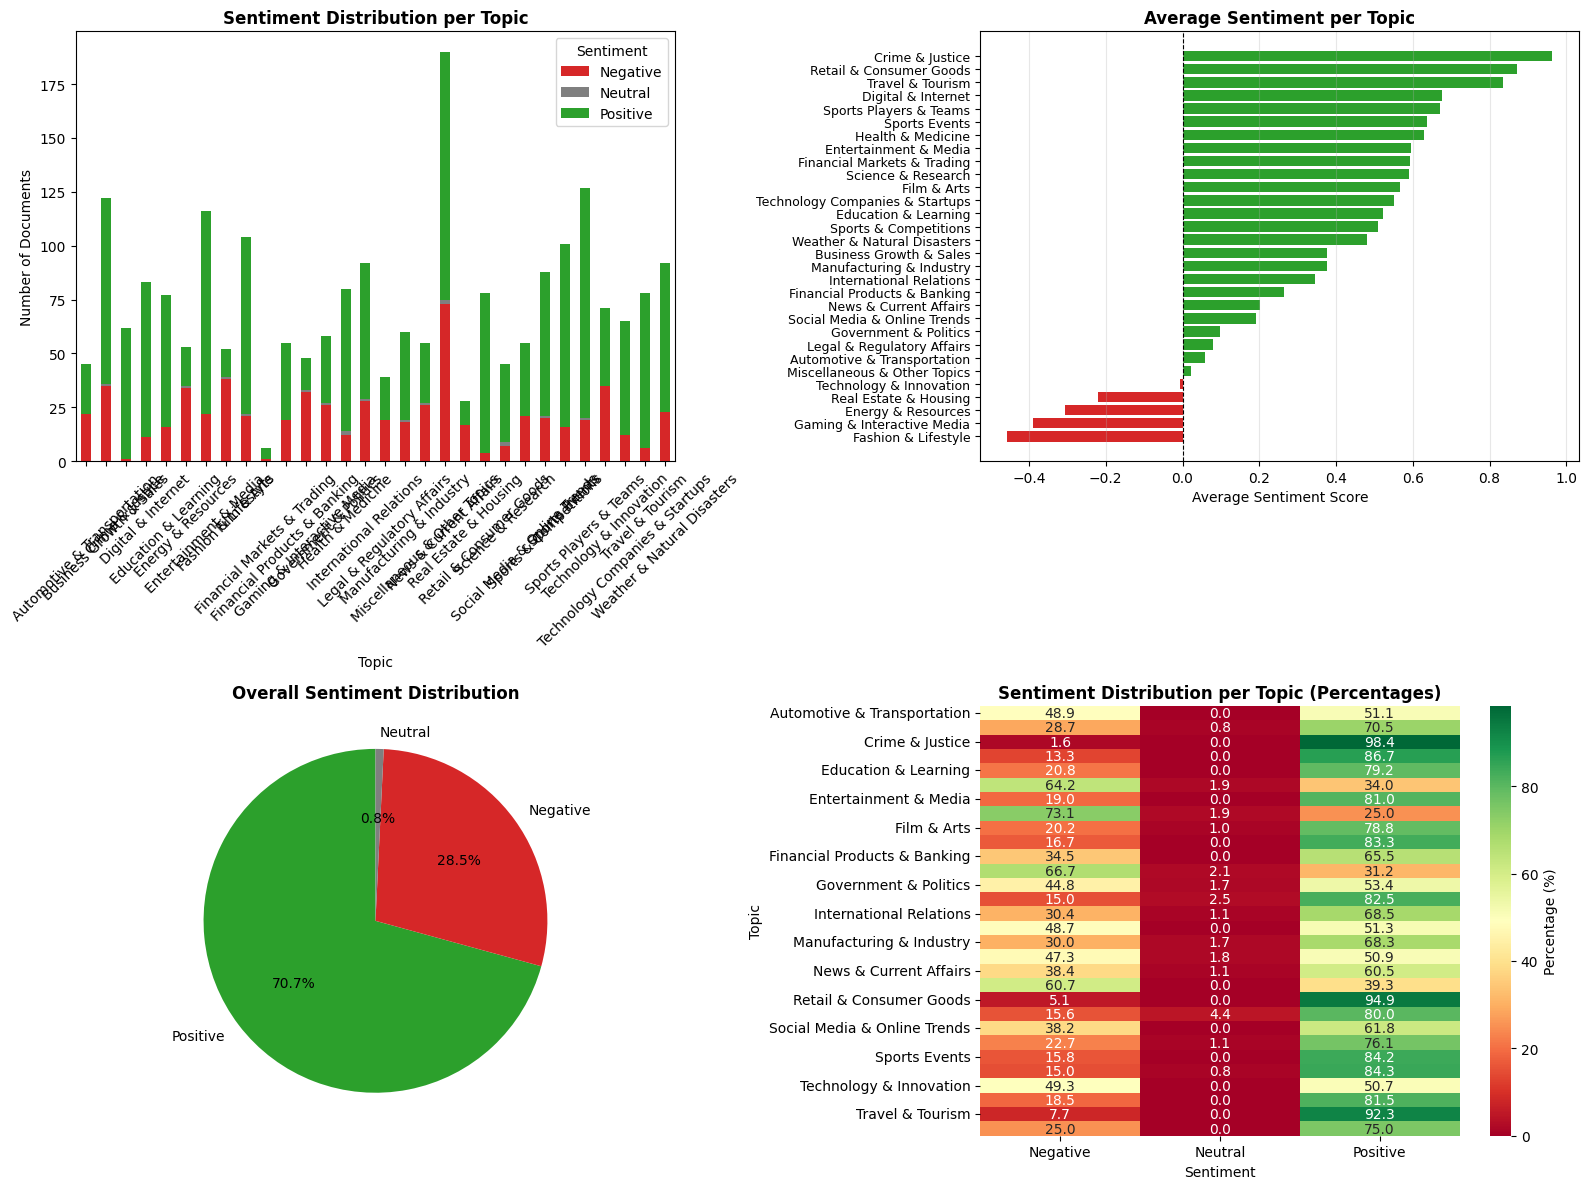

In [ ]:
import numpy as np

# Create visualizations for Topic-Sentiment Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stacked Bar Chart: Topic × Sentiment
topic_sentiment_counts = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)
topic_sentiment_counts = topic_sentiment_counts[['Negative', 'Neutral', 'Positive']]  # Reorder columns

topic_sentiment_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 0],
    color=['#d62728', '#7f7f7f', '#2ca02c']
)
axes[0, 0].set_title('Sentiment Distribution per Topic', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Topic')
axes[0, 0].set_ylabel('Number of Documents')
axes[0, 0].legend(title='Sentiment')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average Sentiment Score per Topic
avg_sentiment_per_topic = df.groupby('topic_label')['sentiment_compound'].mean().sort_values()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in avg_sentiment_per_topic.values]
axes[0, 1].barh(range(len(avg_sentiment_per_topic)), avg_sentiment_per_topic.values, color=colors)
axes[0, 1].set_yticks(range(len(avg_sentiment_per_topic)))
axes[0, 1].set_yticklabels(avg_sentiment_per_topic.index, fontsize=9)
axes[0, 1].set_xlabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment per Topic', fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Pie Chart: Overall Sentiment Distribution
sentiment_counts = df['sentiment_label'].value_counts()
colors_pie = ['#2ca02c', '#d62728', '#7f7f7f']
axes[1, 0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90
)
axes[1, 0].set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

# 4. Heatmap: Topic × Sentiment (normalized percentages)
heatmap_data = topic_sentiment_combo.div(topic_sentiment_combo.sum(axis=1), axis=0) * 100
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 1], cbar_kws={'label': 'Percentage (%)'})
axes[1, 1].set_title('Sentiment Distribution per Topic (Percentages)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Topic')

plt.tight_layout()
plt.savefig('topic_sentiment_analysis.png', dpi=100, bbox_inches='tight')
print("✓ Visualization saved as 'topic_sentiment_analysis.png'")
plt.show()

## Final Summary and Results

Displaying comprehensive summary of all analysis steps, new columns added to the dataset, and prepared visualizations.

In [ ]:
print("\nEXAMPLE DOCUMENTS - TOPIC + SENTIMENT")
print("=" * 80)

# Show interesting examples
examples = []

# Positive articles
positive_docs = df[df['sentiment_label'] == 'Positive'].nlargest(3, 'sentiment_compound')
print("\nPOSITIVE NEWS EXAMPLES:\n")
for idx, row in positive_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()

# Negative articles
negative_docs = df[df['sentiment_label'] == 'Negative'].nsmallest(3, 'sentiment_compound')
print("NEGATIVE NEWS EXAMPLES:\n")
for idx, row in negative_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()

# Neutral articles
neutral_docs = df[df['sentiment_label'] == 'Neutral'].sample(min(3, len(df[df['sentiment_label'] == 'Neutral'])))
print("NEUTRAL NEWS EXAMPLES:\n")
for idx, row in neutral_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()


EXAMPLE DOCUMENTS - TOPIC + SENTIMENT

POSITIVE NEWS EXAMPLES:

Title: Scissor Sisters triumph at Brits
Topic: Film & Arts | Sentiment: Positive (1.000)
Content Preview:  US band Scissor Sisters led the winners at the UK music industry's Brit Awards, walking off with th...

Title: The Producers scoops stage awards
Topic: Crime & Justice | Sentiment: Positive (1.000)
Content Preview:  The Producers has beaten Mary Poppins in the battle of the blockbuster West End musicals at the Oli...

Title: Aviator and Vera take Bafta glory
Topic: Crime & Justice | Sentiment: Positive (1.000)
Content Preview:  Hollywood blockbuster The Aviator and low-budget British movie Vera Drake have shared the main hono...

NEGATIVE NEWS EXAMPLES:

Title: Terror powers expose 'tyranny'
Topic: News & Current Affairs | Sentiment: Negative (-1.000)
Content Preview:  The Lord Chancellor has defended government plans to introduce control orders to keep foreign and B...

Title: MPs' murder sentence concern
Topic: Fas

In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM, AutoTokenizer
import pandas as pd

# 1. Setup Model and Tokenizer
model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# 2. Initialize the pipeline using text2text-generation task
summarizer = pipeline("text2text-generation", model=model, tokenizer=tokenizer)

def generate_summary(text, max_l=130, min_l=30):
    """Summarizes text using the BART model, limited to the first 1024 tokens."""
    results = summarizer(text[:1024], max_length=max_l, min_length=min_l, do_sample=False)
    return results[0]['generated_text']

# 3. Apply summarization to the first 10 documents
print("Generating summaries... this may take a moment.")
sample_df = df.head(10).copy()
sample_df['summary'] = sample_df['content'].apply(generate_summary)

display(sample_df[['title', 'summary']])

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

KeyError: "Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"

In [ ]:
# This cell has been merged into cell 07658003 to ensure function availability.

NameError: name 'generate_summary' is not defined